In [44]:
"""Implementing a python program that uses a Random Forest classification
workflow that categorizes inertial sensor data with a set of activities.
"""

'Implementing a python program that uses a Random Forrest classification\nworkflow that categorizes inertial sensor data with a set of activities.\n'

In [45]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import math
import statistics
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import recall_score, precision_score, f1_score
from sklearn.preprocessing import StandardScaler, label_binarize, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score





In [46]:
os.chdir('/Users/bensonkachappilly/Python directory/Data Science studio/Assignments /Assignment 3')

In [47]:
# For the activity annotation csv file (Video), the x, y min and max are not important to us as this only describes the window selected. We are only interested in the activity label and the start and end time of the activity. We need to map this with the imu data.

In [48]:
def load_data(dataset_path):
    """
    Function load_data reads in the CSV file for imu_data.

     Arguments:
        dataset_path -- The path to the CSV file

     Returns:
        A DataFrame containing the data from the CSV file
    """
    return pd.read_csv(dataset_path, header = None)

In [49]:
dataset_path = "a3_imu_data.csv"

In [50]:
imu_data = load_data(dataset_path)

In [51]:
def load_data1(dataset_path):
    """
    Function load_data reads in the CSV file for imu_data.

     Arguments:
        dataset_path -- The path to the CSV file

     Returns:
        A DataFrame containing the data from the CSV file
    """
    return pd.read_csv(dataset_path)

In [52]:
dataset_path = "a3_activity_annotations.csv"

In [53]:
activity_data = load_data1(dataset_path)

In [54]:
imu_data.head()

,0,1,2,3,4,5,6
0,1598240213,-2402,1710,-380,-1413,-362,223
1,1598240213,-1880,1688,-420,-1469,-597,-23
2,1598240213,-1558,1568,-606,-1535,-872,-195
3,1598240213,-1154,1732,-654,-1293,-976,-335
4,1598240213,-452,2084,-754,-719,-940,-214


In [55]:
imu_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71242 entries, 0 to 71241
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       71242 non-null  int64
 1   1       71242 non-null  int64
 2   2       71242 non-null  int64
 3   3       71242 non-null  int64
 4   4       71242 non-null  int64
 5   5       71242 non-null  int64
 6   6       71242 non-null  int64
dtypes: int64(7)
memory usage: 3.8 MB


In [56]:
imu_data.describe()

,0,1,2,3,4,5,6
count,7.124200e+04,71242.000000,71242.000000,71242.000000,71242.000000,71242.000000,71242.000000
mean,1.598241e+09,-2646.278852,3365.003944,-316.120126,12.639047,-6.352025,-21.447713
std,2.113421e+02,3210.008354,3364.360957,2476.489571,1774.691427,2245.519156,1544.840387
min,1.598240e+09,-32298.000000,-9268.000000,-32768.000000,-24500.000000,-15113.000000,-8864.000000
25%,1.598240e+09,-3502.000000,1522.000000,-1022.000000,-995.750000,-1054.000000,-940.000000
50%,1.598241e+09,-2526.000000,2902.000000,-100.000000,0.000000,11.000000,-3.000000
75%,1.598241e+09,-1154.000000,3982.000000,426.000000,941.000000,1250.000000,702.000000
max,1.598241e+09,12380.000000,32767.000000,20322.000000,13110.000000,23209.000000,14196.000000


In [57]:
# Checking the time stamps of imu data to see if there are any skips in the time stamps
first_column = imu_data.iloc[:, 0]

# FInd if there are differences between consecutive rows.
difference = first_column.diff().dropna()
skips = difference[difference > 1]

print("Rows where skips occur:")
print(skips)

Rows where skips occur:
11155    2.0
16906    2.0
27745    2.0
Name: 0, dtype: float64


In [58]:
def check_NaN(dataframe):
    """
    Function check_NaN prints the total number of NaN values and the number of NaN values in each column of the given DataFrame.

     Arguments:
        dataframe -- The DataFrame to check for NaN values

     Returns:
        None.
    """

    print("Total NaN:", dataframe.isnull().values.sum())
    print("NaN by columns:\n",dataframe.isnull().sum())
    return 

In [59]:
check_NaN(imu_data)

Total NaN: 0
NaN by columns:
 0    0
1    0
2    0
3    0
4    0
5    0
6    0
dtype: int64


In [60]:
activity_data.head()

,image,xmin,ymin,xmax,ymax,label
0,a3.mp4#t=0.0,868.943127,417.331032,919.139168,557.535077,Walking
1,a3.mp4#t=66.2,854.251592,330.392238,926.484935,564.882015,Standing
2,a3.mp4#t=75.4,855.475924,324.882034,929.545709,561.820810,Walking
3,a3.mp4#t=139.333333,849.966598,321.208565,928.933599,563.045281,Standing
4,a3.mp4#t=146.733333,855.475924,327.331004,935.667145,553.249400,Jogging


In [61]:
activity_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   image   34 non-null     object 
 1   xmin    34 non-null     float64
 2   ymin    34 non-null     float64
 3   xmax    34 non-null     float64
 4   ymax    34 non-null     float64
 5   label   34 non-null     object 
dtypes: float64(4), object(2)
memory usage: 1.7+ KB


In [62]:
activity_data.describe()

,xmin,ymin,xmax,ymax
count,34.000000,34.000000,34.000000,34.000000
mean,776.706946,321.766779,838.965904,524.221765
std,151.648701,18.960356,170.150492,77.722607
min,449.622209,302.228954,471.659512,354.882053
25%,827.011074,314.473861,896.795838,550.800387
50%,838.947947,320.596315,913.935953,556.922841
75%,854.251592,325.800387,926.025825,563.045281
max,868.943127,417.331032,937.503587,574.065689


In [63]:
check_NaN(activity_data)

Total NaN: 0
NaN by columns:
 image    0
xmin     0
ymin     0
xmax     0
ymax     0
label    0
dtype: int64


In [64]:
time_track = []
ax_set = []
ay_set = []
az_set = []

gx_set = []
gy_set = []
gz_set = []

activity_set = []

In [65]:
def map_activity(activity_string):
    """
    Function map_activity maps an activity string to a corresponding integer code.

     Arguments:
        activity_string -- The activity string to map

     Returns:
        An integer code corresponding to the activity string
    """
    if activity_string == "Standing":
        return 1
    elif activity_string == "Walking":
        return 2
    elif activity_string == "Jogging":
        return 3
    elif activity_string == "Side-Step":
        return 4
    elif activity_string == "Running":
        return 5

In [66]:
for index, row in imu_data.iterrows():
    time_track.append(float(row.iloc[0]))  
    ax_set.append(float(row.iloc[1]))  
    ay_set.append(float(row.iloc[2]))  
    az_set.append(float(row.iloc[3]))  
    
    gx_set.append(float(row.iloc[4])) 
    gy_set.append(float(row.iloc[5]))  
    gz_set.append(float(row.iloc[6]))  

In [67]:
for index, row in activity_data.iterrows():
    time_stamp = (row.iloc[0].split("="))[1]
    activity_set.append([float(time_stamp), row.iloc[-1], map_activity(row.iloc[-1])])

In [68]:
print(activity_set[:40])

[[0.0, 'Walking', 2], [66.2, 'Standing', 1], [75.4, 'Walking', 2], [139.333333, 'Standing', 1], [146.733333, 'Jogging', 3], [191.4, 'Standing', 1], [197.2, 'Jogging', 3], [239.466667, 'Standing', 1], [244.6, 'Jogging', 3], [320.933333, 'Standing', 1], [328.0, 'Side-Step', 4], [345.066667, 'Standing', 1], [351.533333, 'Side-Step', 4], [371.333333, 'Standing', 1], [376.733333, 'Side-Step', 4], [396.533333, 'Standing', 1], [403.533333, 'Side-Step', 4], [422.4, 'Standing', 1], [426.933333, 'Jogging', 3], [466.866667, 'Standing', 1], [471.066667, 'Walking', 2], [538.133333, 'Standing', 1], [542.333333, 'Side-Step', 4], [561.066667, 'Standing', 1], [565.066667, 'Side-Step', 4], [584.866667, 'Standing', 1], [589.6, 'Running', 5], [614.8, 'Standing', 1], [619.8, 'Running', 5], [648.333333, 'Standing', 1], [653.533333, 'Running', 5], [678.466667, 'Standing', 1], [684.466667, 'Running', 5], [710.666667, 'Standing', 1]]


In [69]:
print(ax_set[:10])

[-2402.0, -1880.0, -1558.0, -1154.0, -452.0, -268.0, -296.0, -552.0, -1016.0, -1688.0]


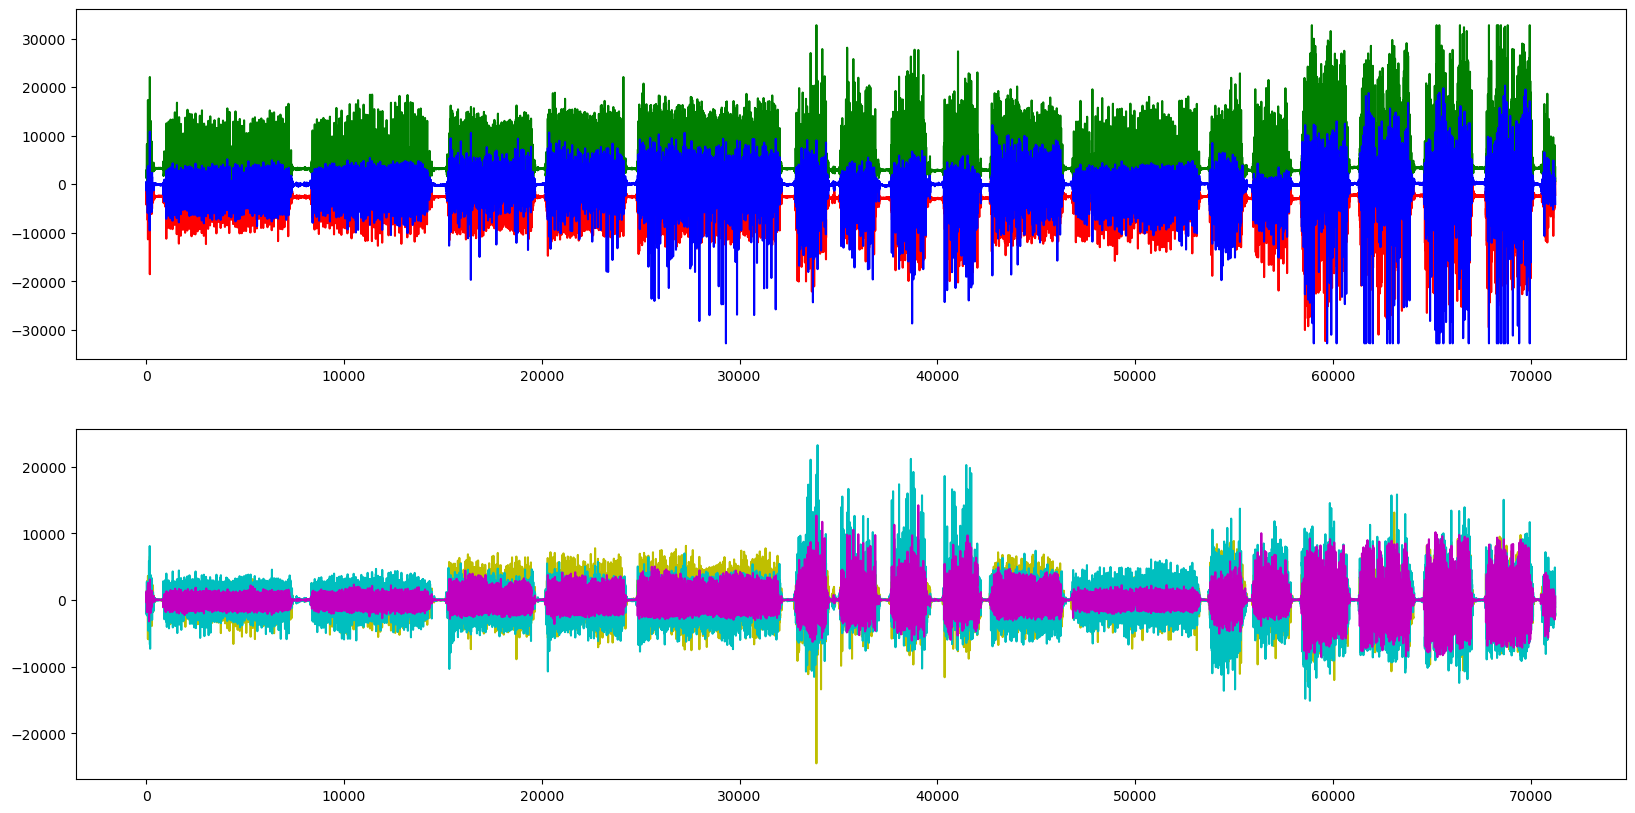

In [70]:
fig, ax1 = plt.subplots(2,1, figsize =(20, 10))

ax1[0].plot(ax_set, color = 'r')
ax1[0].plot(ay_set, color = 'g')
ax1[0].plot(az_set, color = 'b')

ax1[1].plot(gx_set, color = 'y')
ax1[1].plot(gy_set, color = 'c')
ax1[1].plot(gz_set, color = 'm')

In [71]:
start_idx = 810 

start_ts = time_track[start_idx];
print(start_ts)

1598240221.0


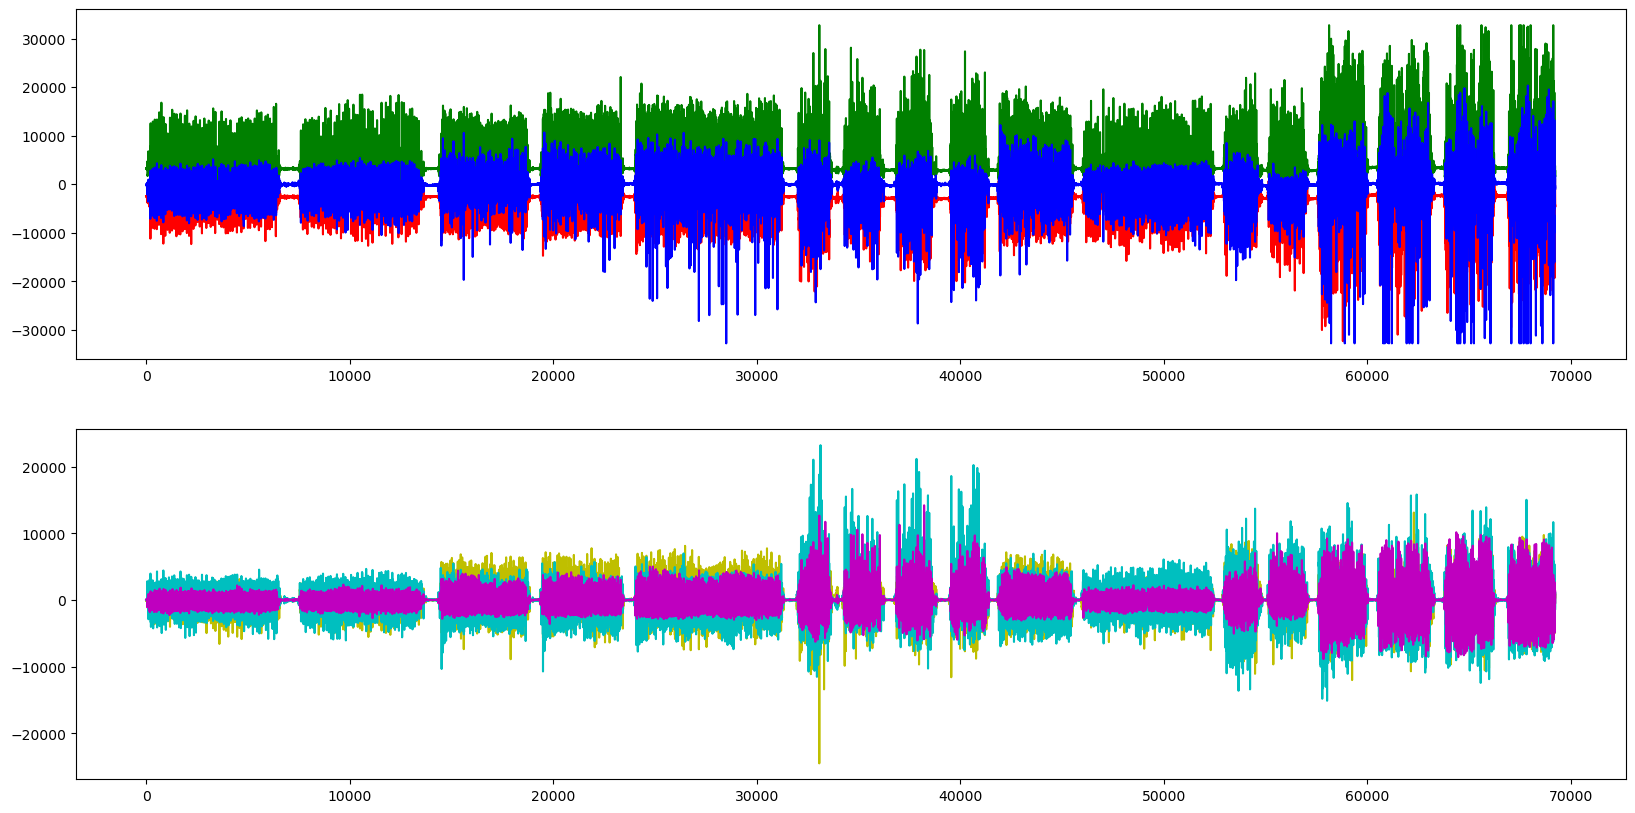

In [72]:
end_idx = time_track.index(start_ts + 711)

fig, ax2 = plt.subplots(2,1, figsize =(20, 10))

ax2[0].plot(ax_set[start_idx:end_idx], color = 'r')
ax2[0].plot(ay_set[start_idx:end_idx], color = 'g')
ax2[0].plot(az_set[start_idx:end_idx], color = 'b')

ax2[1].plot(gx_set[start_idx:end_idx], color = 'y')
ax2[1].plot(gy_set[start_idx:end_idx], color = 'c')
ax2[1].plot(gz_set[start_idx:end_idx], color = 'm')

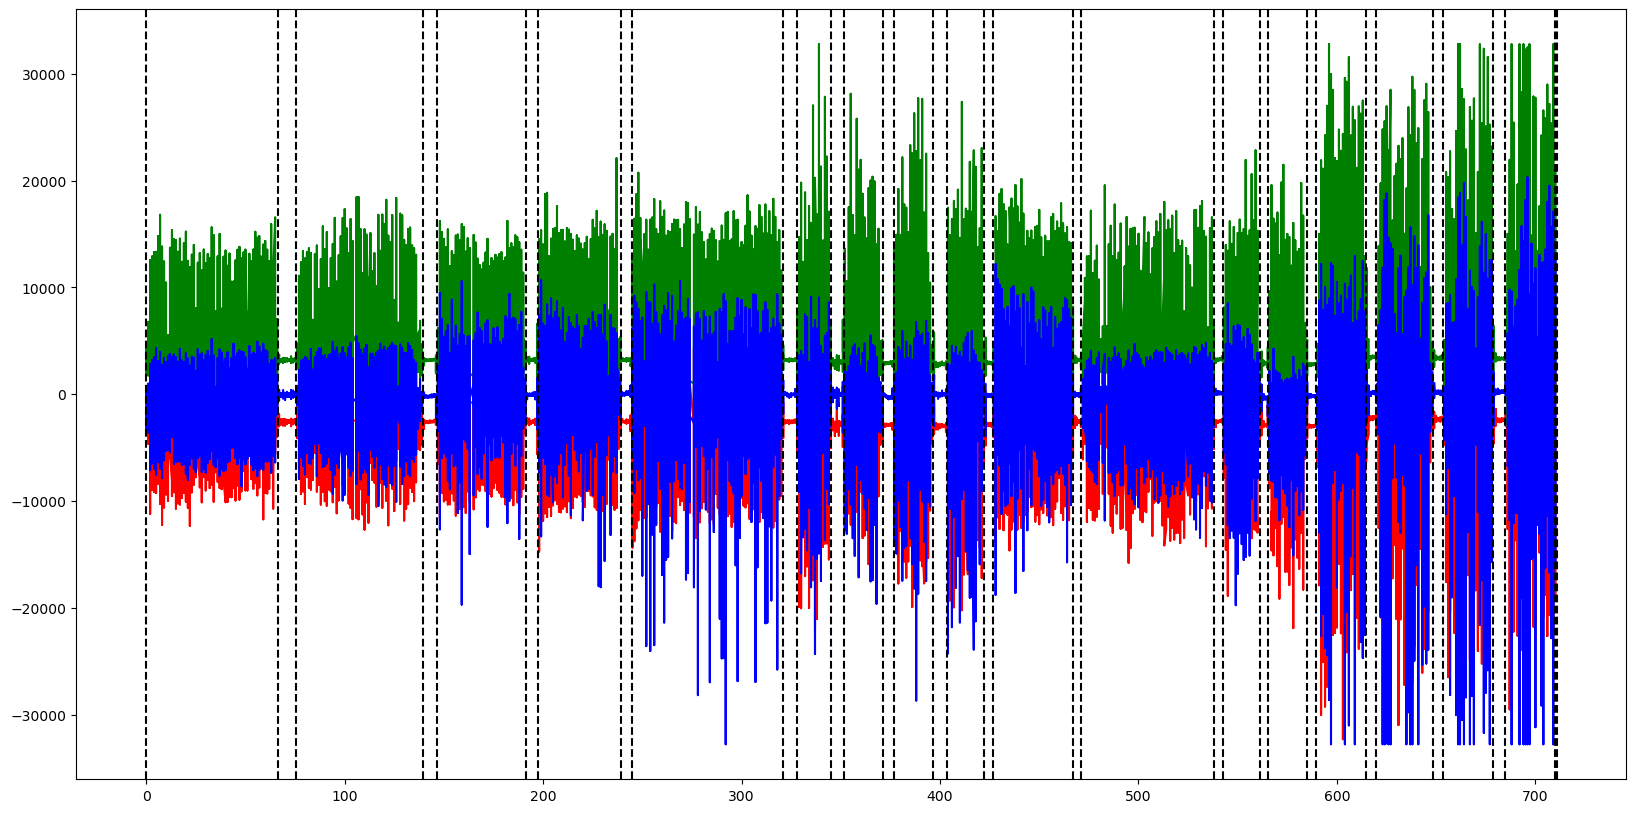

In [73]:
activity_timeseries = []
activity_string_timeseries = []
activity_idx = 0

start_time = time_track[start_idx]
time_track_segment = time_track[start_idx:end_idx]

activity_set.append([time_track_segment[-1] - start_time, "Standing"])

time_track_segment = np.array(time_track_segment) - start_time

fig, ax3 = plt.subplots(figsize =(20, 10))
ax3.plot(time_track_segment, ax_set[start_idx:end_idx], color = 'r')
ax3.plot(time_track_segment, ay_set[start_idx:end_idx], color = 'g')
ax3.plot(time_track_segment, az_set[start_idx:end_idx], color = 'b')

for imu_time_track in time_track_segment:
    current_time = imu_time_track
    next_activity_ts = activity_set[activity_idx + 1][0]
    
    if current_time > next_activity_ts:
        activity_idx = activity_idx + 1
        next_activity_ts = activity_set[activity_idx + 1][0]
    
    activity_timeseries.append(activity_set[activity_idx][2])
    activity_string_timeseries.append(activity_set[activity_idx][1])
    
    
for act in np.array(list(zip(*activity_set)))[0,:]:
    ax3.axvline(float(act), color = 'k', linestyle = '--')
        
        

(array([    0.,  8892., 19331., 19496., 11303., 10218.]),
 array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5]),
 <BarContainer object of 6 artists>)

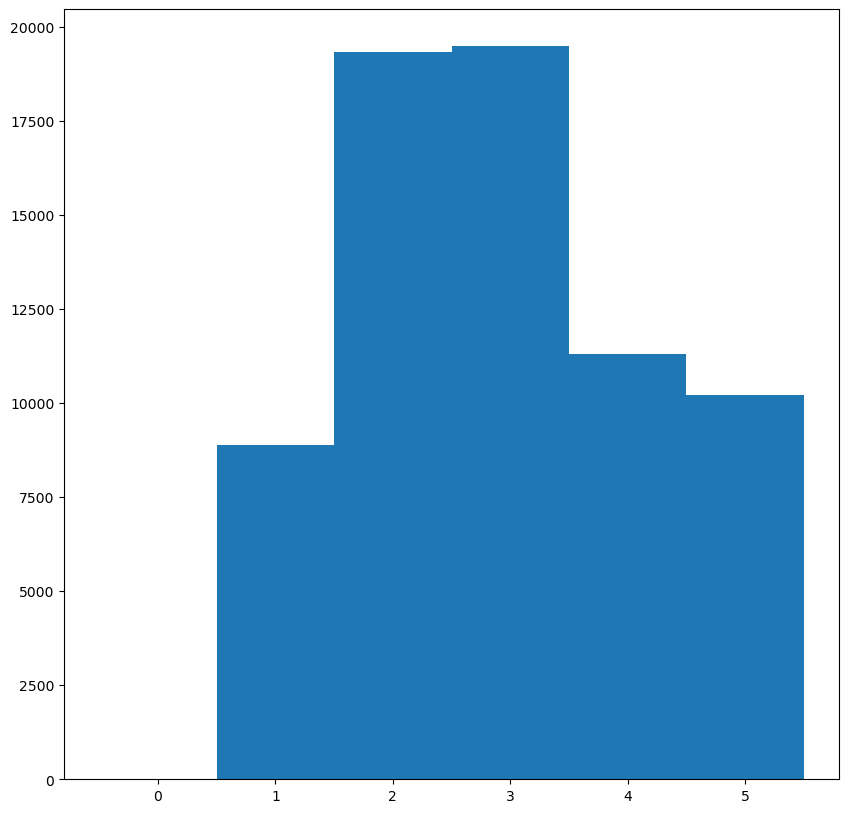

In [74]:
fig, ax4 = plt.subplots(figsize =(10, 10))
ax4.hist(activity_timeseries, bins = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5])

In [75]:
ax_set = ax_set[start_idx:end_idx]
ay_set = ay_set[start_idx:end_idx]
az_set = az_set[start_idx:end_idx]
gx_set = gx_set[start_idx:end_idx]
gy_set = gy_set[start_idx:end_idx]
gz_set = gz_set[start_idx:end_idx]

In [76]:
feature_set = []
target_set = []
window_size = 1.0;

old_feature_row = []
old_activity_code = []


for t in range(int(time_track_segment[0]), int(time_track_segment[-1])):
    
    if t == 60 or t == 61 or t == 62 or t == 105.0 or t == 104.0 or t == 164.0 or t == 163.0 or t == 275.0 or t == 274.0:
        feature_set.append(old_feature_row)
        target_set.append(old_activity_code)
        continue
    
    window_start_idx = list(time_track_segment).index(t)
    window_end_idx = list(time_track_segment).index(t + window_size)
    ax_window = ax_set[window_start_idx:window_end_idx]
    ay_window = ay_set[window_start_idx:window_end_idx]
    az_window = az_set[window_start_idx:window_end_idx]
    gx_window = gx_set[window_start_idx:window_end_idx]
    gy_window = gy_set[window_start_idx:window_end_idx]
    gz_window = gz_set[window_start_idx:window_end_idx]
    
    activity_code = activity_timeseries[window_start_idx]
    
    mu_ax = statistics.mean(ax_window)
    mu_ay = statistics.mean(ay_window)
    mu_az = statistics.mean(az_window)
    mu_gx = statistics.mean(gx_window)
    mu_gy = statistics.mean(gy_window)
    mu_gz = statistics.mean(gz_window)
    
    max_ax = max(ax_window)
    max_ay = max(ay_window)
    max_az = max(az_window)
    max_gx = max(gx_window)
    max_gy = max(gy_window)
    max_gz = max(gz_window)
    
    min_ax = min(ax_window)
    min_ay = min(ay_window)
    min_az = min(az_window)
    min_gx = min(gx_window)
    min_gy = min(gy_window)
    min_gz = min(gz_window)
    
    ax_abs_sum = 0
    ay_abs_sum = 0
    az_abs_sum = 0
    gx_abs_sum = 0
    gy_abs_sum = 0
    gz_abs_sum = 0
    
    a_sum_sq = 0
    g_sum_sq = 0
        
    for i in range(0, len(ax_window)):
        ax_abs_sum = ax_abs_sum + abs(ax_window[i])
        ay_abs_sum = ay_abs_sum + abs(ay_window[i])
        az_abs_sum = az_abs_sum + abs(az_window[i])
        
        gx_abs_sum = gx_abs_sum + abs(gx_window[i])
        gy_abs_sum = gy_abs_sum + abs(gy_window[i])
        gz_abs_sum = gz_abs_sum + abs(gz_window[i])
        
        a_sum_sq = ((ax_window[i] ** 2) + (ay_window[i] ** 2) + (az_window[i] ** 2)) + a_sum_sq
        g_sum_sq = ((gx_window[i] ** 2) + (gy_window[i] ** 2) + (gz_window[i] ** 2)) + g_sum_sq   
        
        
    a_sma = (ax_abs_sum + ay_abs_sum + az_abs_sum) / len(ax_window)
    g_sma = (gx_abs_sum + gy_abs_sum + gz_abs_sum) / len(gx_window)
    
    a_av_intensity = math.sqrt(a_sum_sq) / len(ax_window)
    g_av_intensity = math.sqrt(g_sum_sq) / len(gx_window)
    
    feature_row = [mu_ax, mu_ay, mu_az, mu_gx, mu_gy, mu_gz, max_ax, max_ay, max_az, max_gx, max_gy, max_gz, min_ax, min_ay, min_az, min_gx, min_gy, min_gz, a_sma, g_sma, a_av_intensity, g_av_intensity]
    
    old_feature_row = feature_row
    old_activity_code = activity_code
    
    feature_set.append(feature_row)
    target_set.append(activity_code)

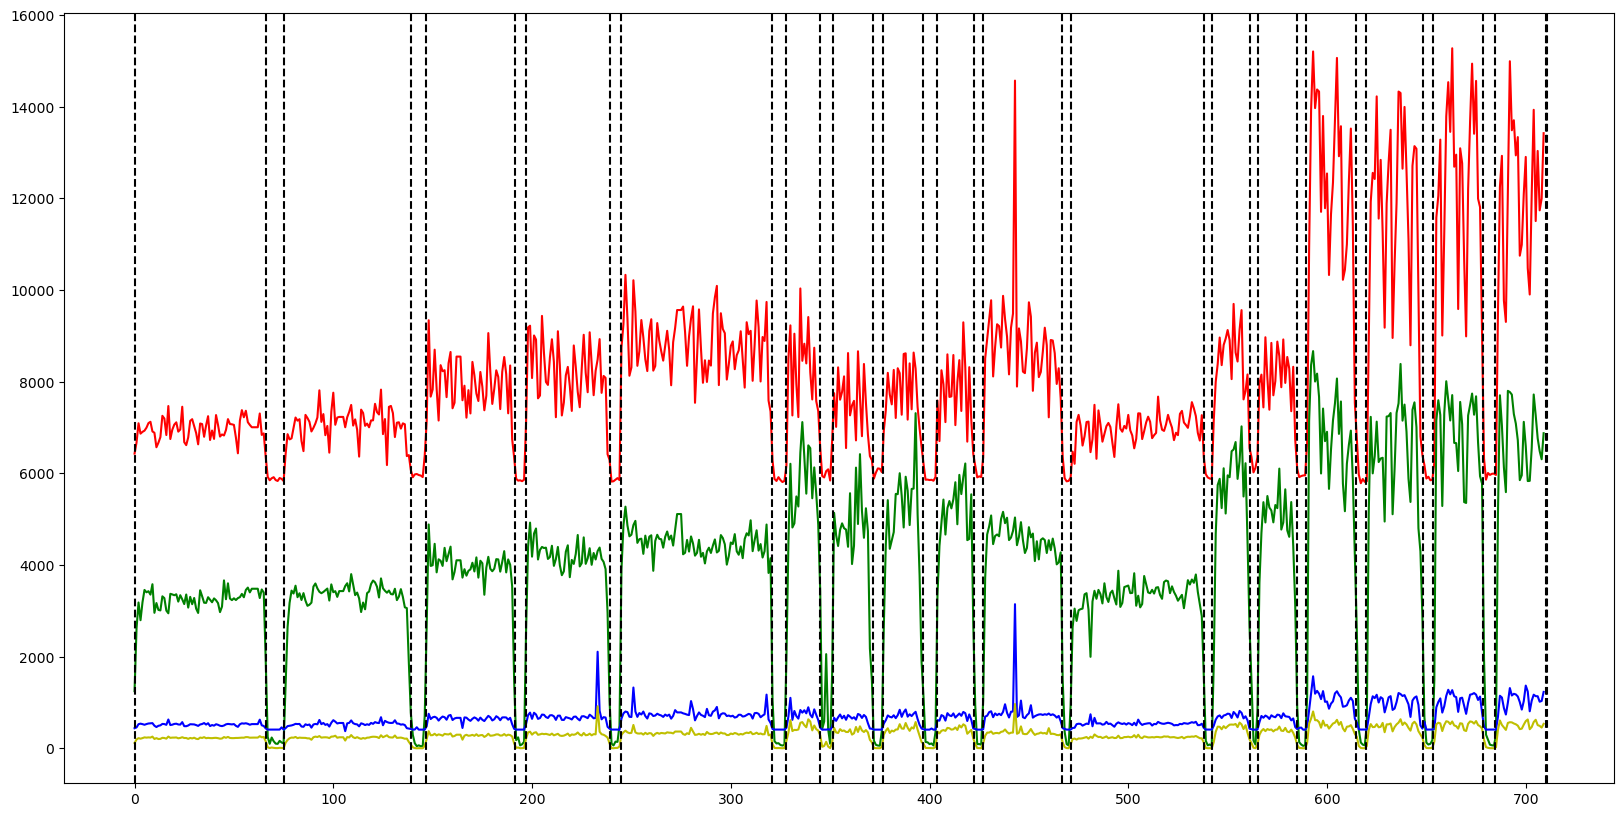

In [77]:
fig, ax5 = plt.subplots(figsize =(20, 10))
ax5.plot(range(0, len(np.array(feature_set))), np.array(feature_set)[:,18], color = 'r')
ax5.plot(range(0, len(np.array(feature_set))), np.array(feature_set)[:,19], color = 'g')
ax5.plot(range(0, len(np.array(feature_set))), np.array(feature_set)[:,20], color = 'b')
ax5.plot(range(0, len(np.array(feature_set))), np.array(feature_set)[:,21], color = 'y')

for act in np.array(list(zip(*activity_set)))[0,:]:
    ax5.axvline(float(act), color = 'k', linestyle = '--')

In [78]:
# Convert to numpy arrays

feature_set = np.array(feature_set)[:, 4:]
target_set = np.array(target_set)

In [79]:
# Split the data into a training set and a test set.

X_train, X_test, y_train, y_test = train_test_split(feature_set, target_set, test_size = 0.2, random_state = 42)
print("X train/test", X_train.shape, X_test.shape)
print("y_train/test", y_train.shape, y_test.shape)

X train/test (568, 18) (142, 18)
y_train/test (568,) (142,)


In [80]:
# Optimize the max_depth parameter of the Random Forest Classifier using 10-fold cross-validation on the training set.

# Initialize variables
best_f1_score = 0
precision_score_final = 0
recall_score_final = 0
opt_max_depth = 0
best_clf = None

# Iterate over the max_depth parameter from a range of 1-19 to find the best depth for the Random Forest Classifier
for max_depth_iter in range(1, 20):
    
    clf = RandomForestClassifier(n_estimators = 100, random_state = 42, max_features = 'sqrt', max_depth = max_depth_iter, min_samples_split = 50)
    
    # Performing a 10-fold cross-validation on the training set to get predictions. 
    y_predicted = cross_val_predict(clf, X_train, y_train, cv = 10)
    
    # Calculating the F1 score for the current max_depth
    current_f1 = np.mean(f1_score(y_train, y_predicted, average = "weighted"))
    print(f"Cross-validation F1 score for max_depth = {max_depth_iter}:  {current_f1}") 

    # Check if the current F1 score is better than the best F1 score
    if current_f1 > best_f1_score:
        opt_max_depth = max_depth_iter
        best_f1_score = current_f1
        
        # Calculate the precision and recall scores for the best F1 score
        precision_score_final = (precision_score(y_train, y_predicted, average = "weighted"))
        recall_score_final = (recall_score(y_train, y_predicted, average = "weighted"))
        best_clf = clf
        
print(f"\nBest F1 score was:): {best_f1_score}, using max_depth of {opt_max_depth}.")
print(f"Corresponding precision: {precision_score_final}.")
print(f"Corresponding recall: {recall_score_final}.")


Cross-validation F1 score for max_depth = 1:  0.3832572137518553


/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Cross-validation F1 score for max_depth = 2:  0.9008238049590155
Cross-validation F1 score for max_depth = 3:  0.9367782593650149
Cross-validation F1 score for max_depth = 4:  0.9317619186251801
Cross-validation F1 score for max_depth = 5:  0.933489691338259
Cross-validation F1 score for max_depth = 6:  0.9354559550286456
Cross-validation F1 score for max_depth = 7:  0.9353839328382776
Cross-validation F1 score for max_depth = 8:  0.933556180010285
Cross-validation F1 score for max_depth = 9:  0.9353839328382776
Cross-validation F1 score for max_depth = 10:  0.9353839328382776
Cross-validation F1 score for max_depth = 11:  0.9353839328382776
Cross-validation F1 score for max_depth = 12:  0.9353839328382776
Cross-validation F1 score for max_depth = 13:  0.9353839328382776
Cross-validation F1 score for max_depth = 14:  0.9353839328382776
Cross-validation F1 score for max_depth = 15:  0.9353839328382776
Cross-validation F1 score for max_depth = 16:  0.9353839328382776
Cross-validation F1 

In [81]:
# Train the Random Forest classifier with the best max_depth parameter
fitted_model = best_clf.fit(X_train, y_train)
y_train_predicted = fitted_model.predict(X_train)
y_test_predicted = fitted_model.predict(X_test)

Test: [0.94366197 0.98026316 0.9689441  0.93877551 0.86046512]
Test: [0.89333333 0.91411043 0.98734177 0.93877551 1.        ]
Test: [0.91780822 0.94603175 0.97805643 0.93877551 0.925     ]


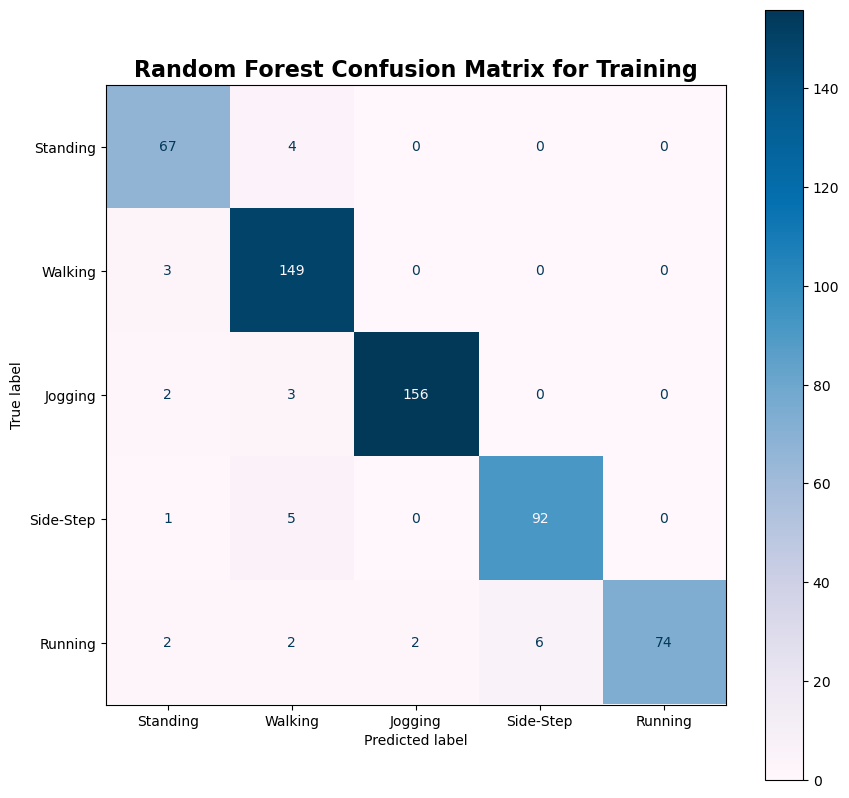

In [82]:
# Creating confusion matrix for train
conf_matrix_train = confusion_matrix(y_train, y_train_predicted)

fig, ax6 = plt.subplots(figsize = (10,10))
disp = ConfusionMatrixDisplay(confusion_matrix = conf_matrix_train, display_labels = ["Standing", "Walking", "Jogging", "Side-Step", "Running"])

disp.plot(ax = ax6, cmap = plt.cm.PuBu)

ax6.set_title('Random Forest Confusion Matrix for Training', fontsize = 16, fontweight = 'bold')

print("Test:", recall_score(y_train, y_train_predicted, average = None))
print("Test:", precision_score(y_train, y_train_predicted, average = None))
print("Test:", f1_score(y_train, y_train_predicted, average = None))

Test: [0.95       0.97826087 0.95238095 0.8125     0.77777778]
Test: [0.86363636 0.91836735 1.         0.76470588 1.        ]
Test: [0.9047619  0.94736842 0.97560976 0.78787879 0.875     ]


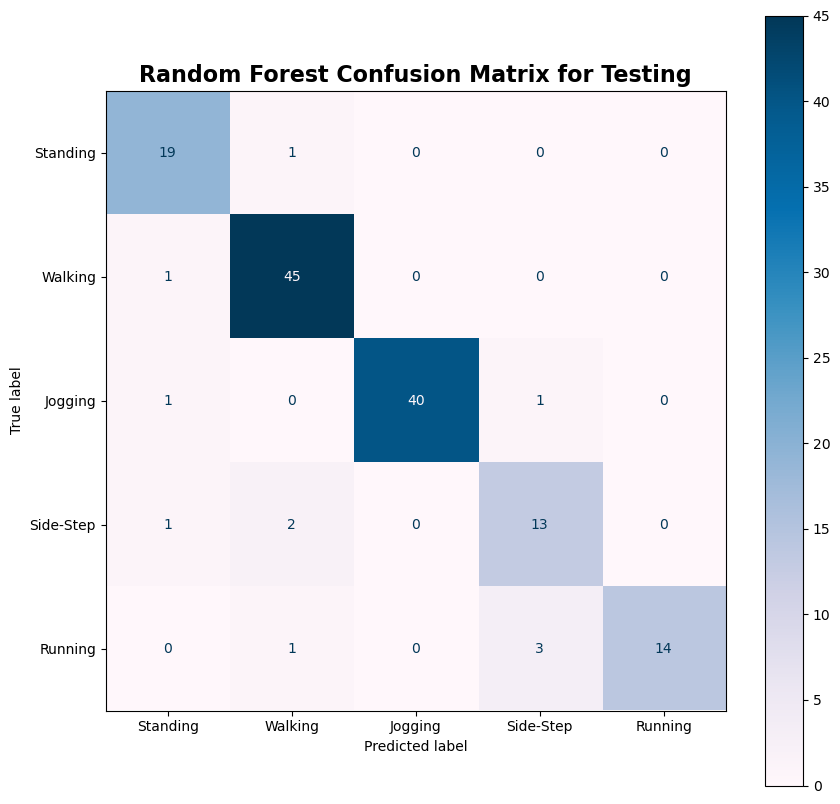

In [83]:
# Creating confusion matrix for test
conf_matrix_test = confusion_matrix(y_test, y_test_predicted)

fig, ax7 = plt.subplots(figsize = (10,10))
disp = ConfusionMatrixDisplay(confusion_matrix = conf_matrix_test, display_labels = ["Standing", "Walking", "Jogging", "Side-Step", "Running"])

disp.plot(ax = ax7, cmap = plt.cm.PuBu)

ax7.set_title('Random Forest Confusion Matrix for Testing', fontsize = 16, fontweight = 'bold')

print("Test:", recall_score(y_test, y_test_predicted, average = None))
print("Test:", precision_score(y_test, y_test_predicted, average = None))
print("Test:", f1_score(y_test, y_test_predicted, average = None))

In [84]:
# We are only interested in the last 4 columns which construct features based on the Signal Magnitude area and Average Intensity of the acceleration and gyroscope data.

feature_titles = ["a_smv", "g_smv", "a_av_intensity", "g_av_intensity"]

# Convert the X_train numpy array to a pandas DataFrame
X_train_DataFrame = pd.DataFrame(X_train)

# Extract the last 4 columns
last_4_columns = X_train_DataFrame.iloc[:, -4:]

# Select the last 4 important features from the trained classifier
last_4_trained_classifier = best_clf.feature_importances_[-4:]

# Create a DataFrame to display the feature importance with the corresponding feature title
best_features_dataframe = pd.DataFrame(data = last_4_trained_classifier, index = feature_titles, columns = ["Importance"])

# Sort the DataFrame by importance in descending order
best_features_dataframe = best_features_dataframe.sort_values(by = "Importance", ascending = False)

# Display the top 2 features
top_2_features = best_features_dataframe.index[:2]

print("Top 2 features are:")
for i, feature in enumerate(top_2_features, start = 1):
    print(f"{i}. {feature} (Importance: {best_features_dataframe.loc[feature, 'Importance']})")

Top 2 features are:
1. g_av_intensity (Importance: 0.1419672866413032)
2. g_smv (Importance: 0.1104843098826786)


Text(0.5, 1.0, 'Decision Boundaries for Random Forest classifier with 2 Best features using Testing Data Points')

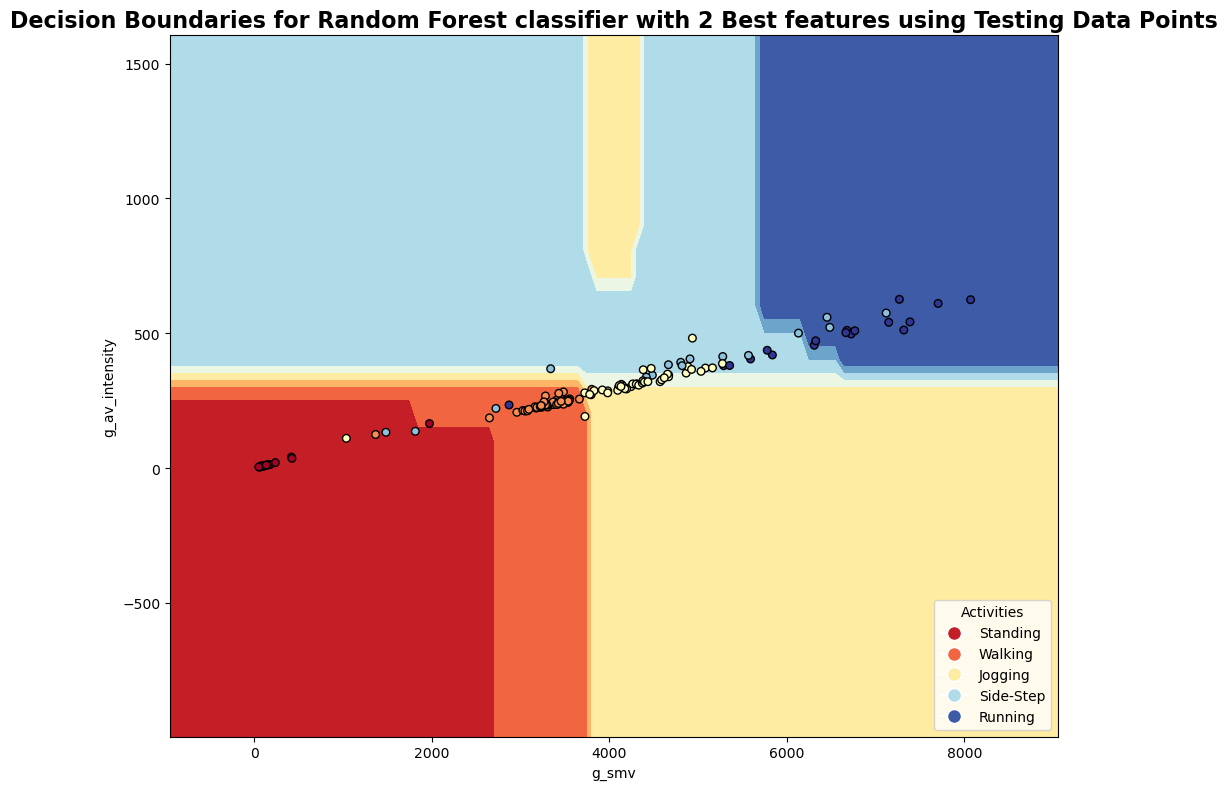

In [85]:
# Split the data into training and testing sets but only using the top 2 features
X_train, X_test, y_train, y_test = train_test_split(feature_set[:, [15, 17]], target_set, test_size=0.2, random_state=42)

# Selecting g_av_intensity & g_smv columns for visualization. 
target_names = ["Standing", "Walking", "Jogging", "Side-Step", "Running"]  # Labels for each class
plot_colors = ['#C41E27','#F16640','#FEECA2','#B0DCEA','#3D5BA7']  # Custom colors for the classes

# Train the Random Forest classifier with the training set
clf = RandomForestClassifier(max_depth=max_depth_iter, n_estimators=100, max_features="sqrt", 
                             random_state=42, min_samples_split=50).fit(X_train, y_train)

# Define a function to plot decision boundaries using testing data
def plot_decision_boundaries(X, y, clf, ax, class_labels):
    """
    Function plot_decision_boundaries plots the decision boundaries of a classifier and the original data points.

     Arguments:
        X -- Feature data
        y -- Labels
        clf -- Classifier
        ax -- Axis object to plot on
        class_labels -- List of class labels

     Returns:
        None
    """
    h = 100  # Step size in the mesh grid
    
    # Define the limits for the mesh grid based on the feature space
    x_min, x_max = X[:, 0].min() - 1000, X[:, 0].max() + 1000
    y_min, y_max = X[:, 1].min() - 1000, X[:, 1].max() + 1000
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), 
                         np.arange(y_min, y_max, h))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)
    
    # Predict across the mesh grid
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot the decision boundary
    ax.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu)
    
    # Plot the original testing data points
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.RdYlBu, edgecolor='k')
    
    # Create a legend mapping
    handles, _ = scatter.legend_elements()
    unique_classes = np.unique(y)

    #  Valid class indices are mapped to class labels
    valid_classes = unique_classes[unique_classes < len(class_labels)]
    labels_dict = {i: class_labels[i] for i in valid_classes}
    labels = [labels_dict[unique_class] for unique_class in valid_classes]
    
    # Manually create identies for all class labels
    class_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=plot_colors[i], 
                                markersize=10, label=class_labels[i]) for i in range(len(class_labels))]
    
    # Add legend for all classes
    ax.legend(handles=class_handles, loc="lower right", title="Activities")

# Plot decision boundaries for the testing data
fig, ax8 = plt.subplots(figsize=(10, 8))
plot_decision_boundaries(X_test, y_test, clf, ax8, target_names)
ax8.set_xlabel('g_smv')
ax8.set_ylabel('g_av_intensity')
ax8.set_title('Decision Boundaries for Random Forest classifier with 2 Best features using Testing Data Points', fontweight='bold', fontsize=16)